In [1]:
from tm_matrix import tm_matrix, plot_umap, plot_umap_clusters

/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# You should have already run the bash scripts, and got the {model}_foldseek_results.tsv and {model}_clusters_cluster.tsv. 
exp_dir="/workspaces/Effector-Structure-Prediction/06_clustering/exp_foldseek_results.tsv"
esm_dir="/workspaces/Effector-Structure-Prediction/06_clustering/esm_foldseek_results.tsv"
af2_dir="/workspaces/Effector-Structure-Prediction/06_clustering/af2_foldseek_results.tsv"
af3_dir="/workspaces/Effector-Structure-Prediction/06_clustering/af3_foldseek_results.tsv"

exp_clusters_dir="/workspaces/Effector-Structure-Prediction/06_clustering/experimental_clusters_cluster.tsv"
esm_clusters_dir="/workspaces/Effector-Structure-Prediction/06_clustering/esm_clusters_cluster.tsv"
af2_clusters_dir="/workspaces/Effector-Structure-Prediction/06_clustering/af2_clusters_cluster.tsv"
af3_clusters_dir="/workspaces/Effector-Structure-Prediction/06_clustering/af3_clusters_cluster.tsv"

exp_matrix = tm_matrix (exp_dir)
esm_matrix = tm_matrix (esm_dir)
af2_matrix = tm_matrix (af2_dir)
af3_matrix = tm_matrix (af3_dir)

exp_embedding=plot_umap(exp_matrix)
esm_embedding = plot_umap (esm_matrix)
af2_embedding = plot_umap (af2_matrix)
af3_embedding = plot_umap (af3_matrix)

/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/workspaces/Effector-Structure-Prediction/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: U

/workspaces/Effector-Structure-Prediction/06_clustering/tm_matrix.py:83: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  cluster_numbers = pd.factorize(colors)[0]


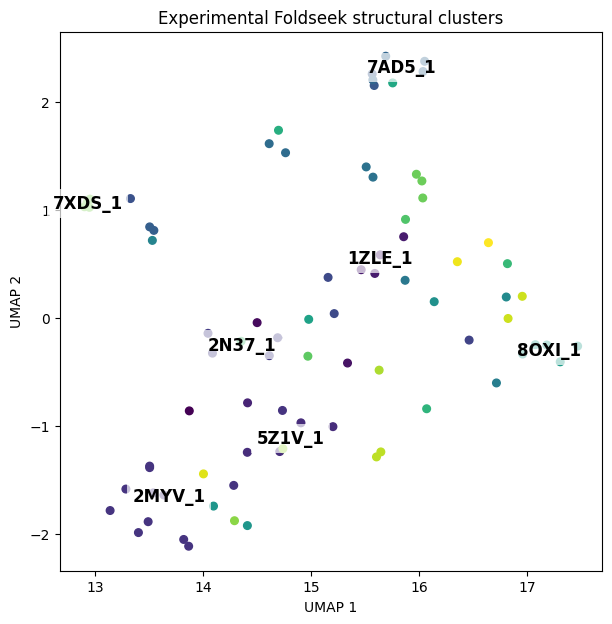

In [3]:
plot_umap_clusters(exp_clusters_dir, exp_embedding, exp_matrix, "Experimental Foldseek structural clusters")

/workspaces/Effector-Structure-Prediction/06_clustering/tm_matrix.py:83: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  cluster_numbers = pd.factorize(colors)[0]


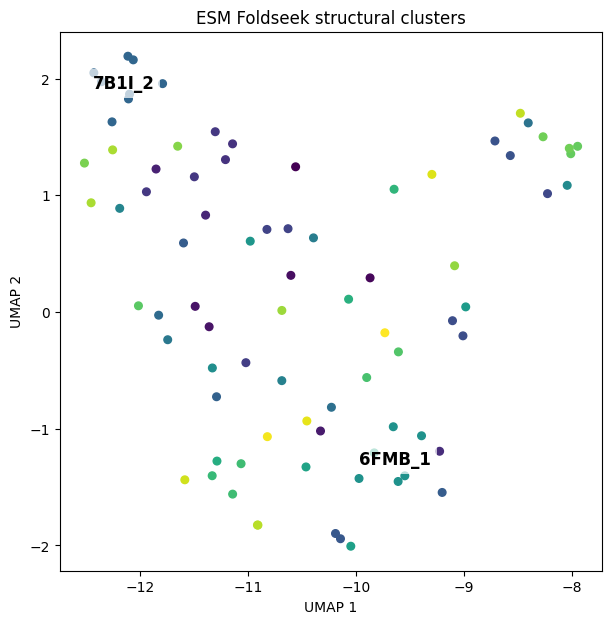

In [4]:
plot_umap_clusters(esm_clusters_dir, esm_embedding, esm_matrix, "ESM Foldseek structural clusters")

/workspaces/Effector-Structure-Prediction/06_clustering/tm_matrix.py:83: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  cluster_numbers = pd.factorize(colors)[0]


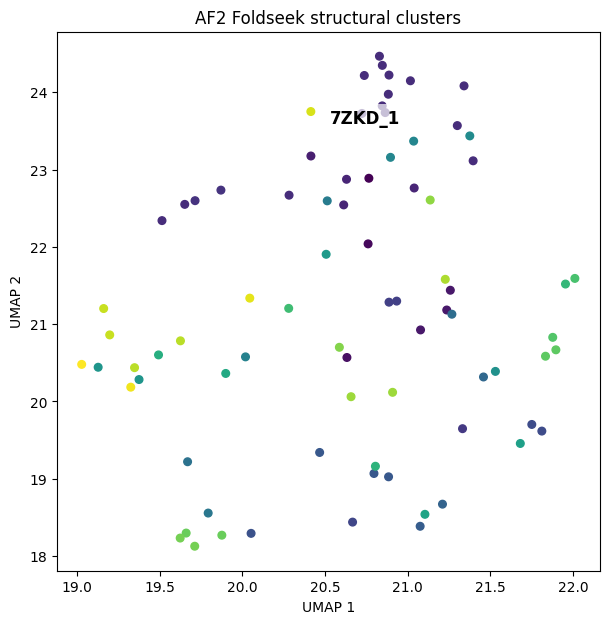

In [5]:
plot_umap_clusters(af2_clusters_dir, af2_embedding, af2_matrix, "AF2 Foldseek structural clusters")

/workspaces/Effector-Structure-Prediction/06_clustering/tm_matrix.py:83: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  cluster_numbers = pd.factorize(colors)[0]


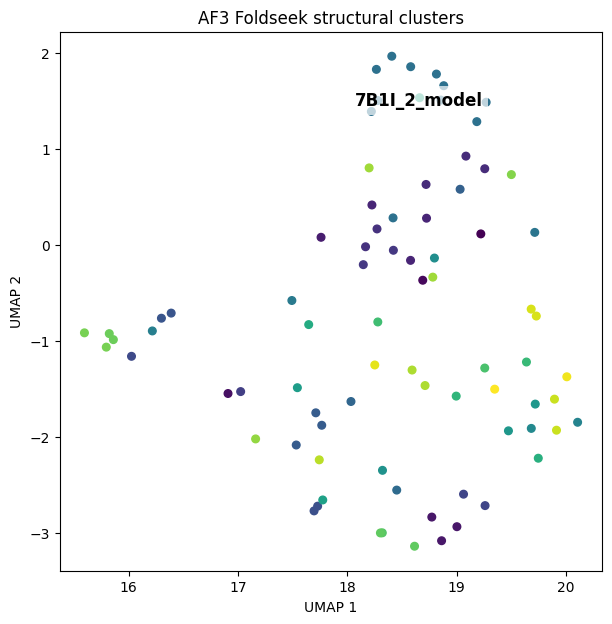

In [6]:
plot_umap_clusters(af3_clusters_dir, af3_embedding, af3_matrix, "AF3 Foldseek structural clusters")

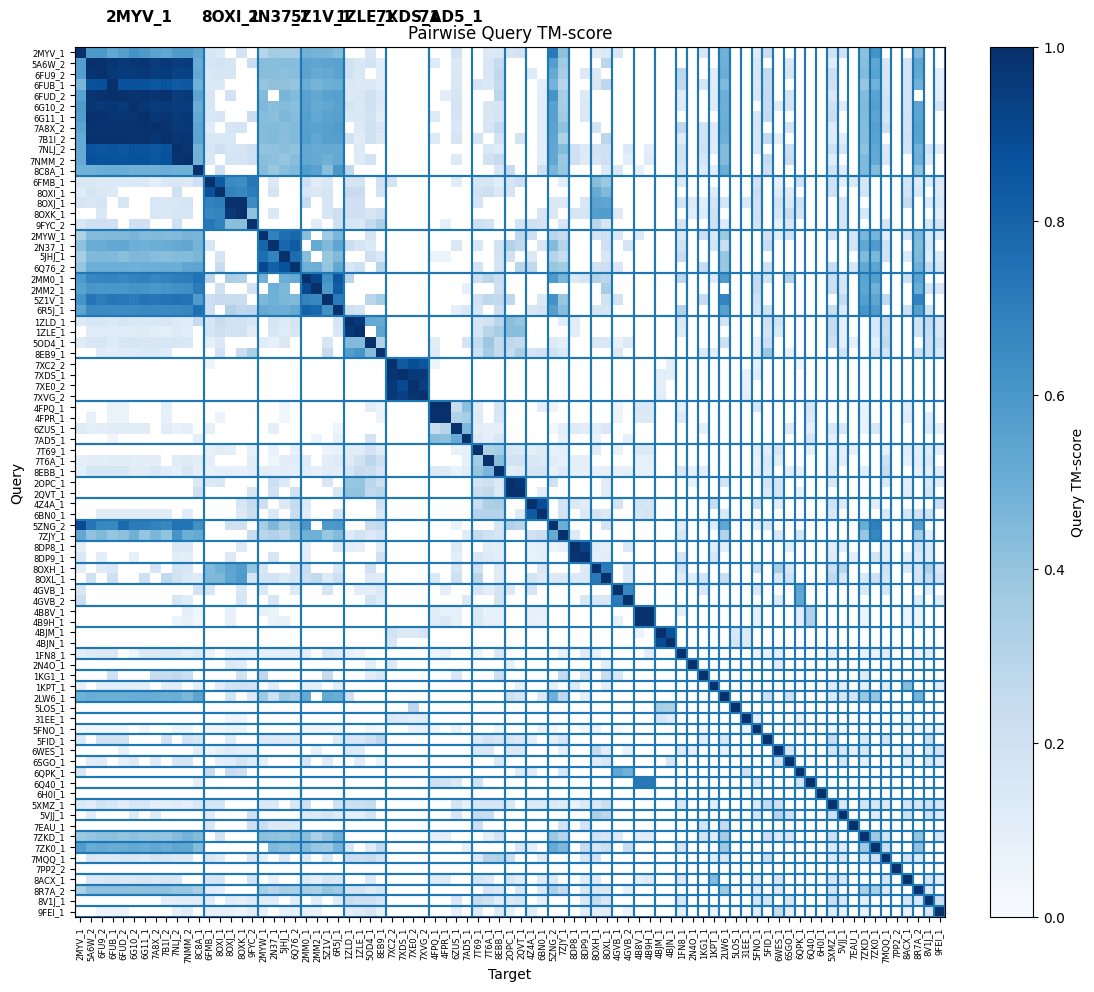

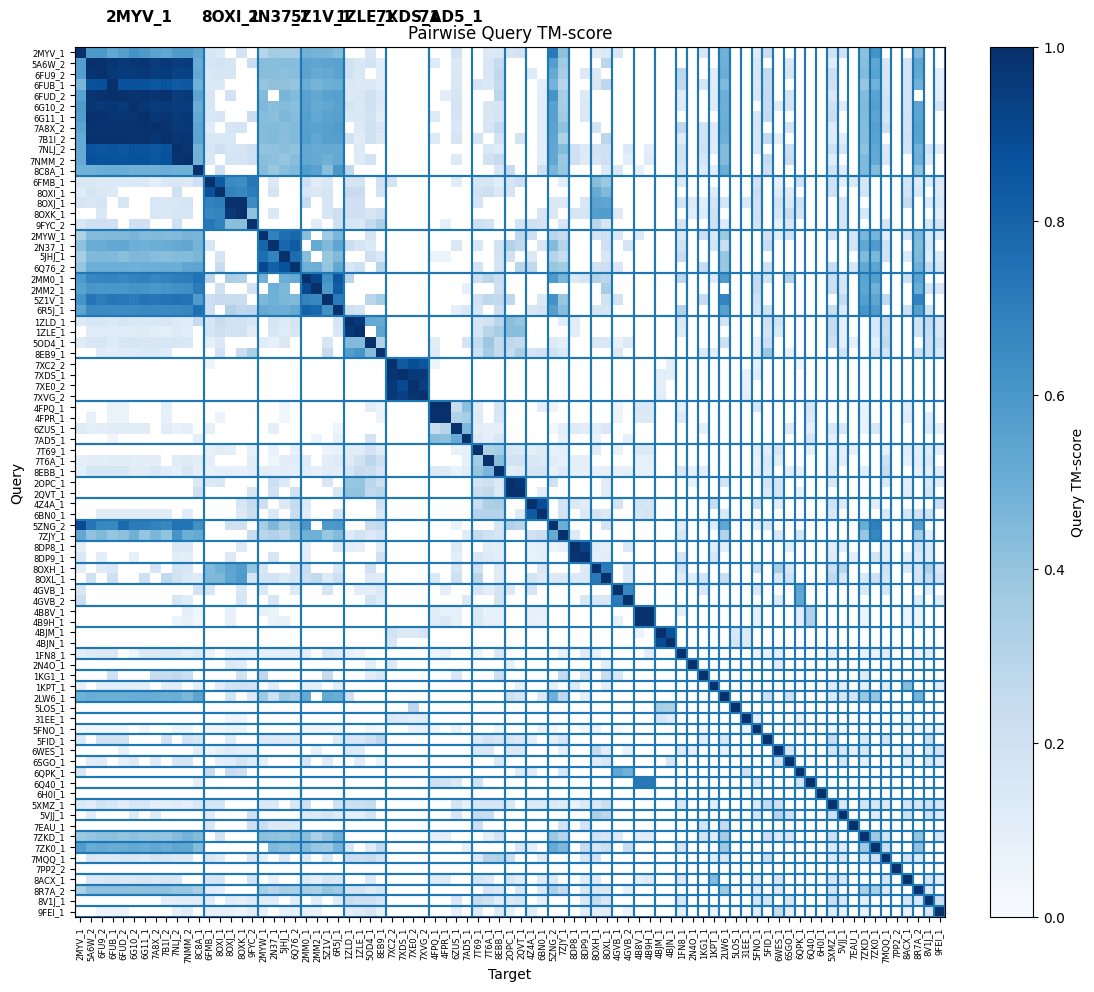

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def tm_matrix(foldseek_dir):
    """
    Create a query-TM-score matrix.

    Rows    = query proteins
    Columns = target proteins
    Value   = query TM-score
    """

    df = pd.read_csv(
        foldseek_dir,
        sep="\t",
        names=[
            "query",
            "target",
            "alnlen",
            "alntmscore",
            "qtmscore",
            "ttmscore",
            "rmsd"
        ]
    )

    proteins = sorted(
        set(df["query"]).union(df["target"])
    )

    # Start with NaN so missing comparisons remain visible
    matrix = pd.DataFrame(
        np.nan,
        index=proteins,
        columns=proteins
    )

    # Diagonal = perfect self-similarity
    np.fill_diagonal(matrix.values, 1.0)

    # Fill matrix with QUERY TM-score
    for _, row in df.iterrows():
        matrix.loc[row["query"], row["target"]] = row["qtmscore"]

    return matrix


def order_by_clusters(matrix, clusters_dir):
    """
    Reorder the matrix so proteins belonging to the same
    Foldseek cluster are grouped together.
    """

    clusters = pd.read_csv(
        clusters_dir,
        sep="\t",
        header=None,
        names=["cluster", "protein"]
    )

    # Keep only proteins that occur in the matrix
    clusters = clusters[
        clusters["protein"].isin(matrix.index)
    ].copy()

    # Number of members in each cluster
    cluster_sizes = clusters["cluster"].value_counts()

    # Sort clusters:
    # largest clusters first
    cluster_order = (
        cluster_sizes
        .sort_values(ascending=False)
        .index
    )

    ordered_proteins = []

    for cluster in cluster_order:

        members = clusters.loc[
            clusters["cluster"] == cluster,
            "protein"
        ].tolist()

        # Sort members alphabetically within cluster
        members = sorted(members)

        ordered_proteins.extend(members)

    # Add anything that was not found in clusters
    remaining = [
        p for p in matrix.index
        if p not in ordered_proteins
    ]

    ordered_proteins.extend(sorted(remaining))

    matrix_ordered = matrix.loc[
        ordered_proteins,
        ordered_proteins
    ]

    return matrix_ordered, clusters


def plot_tm_heatmap(
    matrix,
    clusters,
    min_cluster_size=4,
    cluster_names=None
):
    """
    Plot a cluster-ordered TM-score heatmap.

    cluster_names:
        Dictionary allowing manual renaming of clusters.

        Example:
        {
            "1": "MAX",
            "2": "AvrLm",
            "5": "Unknown"
        }
    """

    if cluster_names is None:
        cluster_names = {}

    # --------------------------------------------------
    # Get cluster for each protein
    # --------------------------------------------------

    cluster_map = dict(
        zip(
            clusters["protein"],
            clusters["cluster"]
        )
    )

    # Cluster corresponding to each row/column
    protein_clusters = [
        cluster_map.get(protein, "Unclustered")
        for protein in matrix.index
    ]

    # --------------------------------------------------
    # Create figure
    # --------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    im = ax.imshow(
        matrix.values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    # --------------------------------------------------
    # Axis labels
    # --------------------------------------------------

    ax.set_xticks(np.arange(len(matrix)))
    ax.set_yticks(np.arange(len(matrix)))

    ax.set_xticklabels(
        matrix.columns,
        rotation=90,
        fontsize=6
    )

    ax.set_yticklabels(
        matrix.index,
        fontsize=6
    )

    ax.set_xlabel("Target")
    ax.set_ylabel("Query")

    # --------------------------------------------------
    # Colorbar
    # --------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        "Query TM-score"
    )

    # --------------------------------------------------
    # Draw cluster boundaries
    # --------------------------------------------------

    boundaries = []

    current_cluster = protein_clusters[0]
    start = 0

    for i, cluster in enumerate(
        protein_clusters + [None]
    ):

        if cluster != current_cluster:

            end = i

            # Draw boundary around cluster
            ax.axhline(
                start - 0.5,
                linewidth=1.5
            )

            ax.axhline(
                end - 0.5,
                linewidth=1.5
            )

            ax.axvline(
                start - 0.5,
                linewidth=1.5
            )

            ax.axvline(
                end - 0.5,
                linewidth=1.5
            )

            boundaries.append(
                (start, end, current_cluster)
            )

            start = i
            current_cluster = cluster

    # --------------------------------------------------
    # Add cluster labels
    # --------------------------------------------------

    for start, end, cluster in boundaries:

        cluster_size = end - start

        # Only label clusters with >= 4 members
        if cluster_size < min_cluster_size:
            continue

        # Manual name if supplied
        label = cluster_names.get(
            str(cluster),
            str(cluster)
        )

        centre = (start + end - 1) / 2

        # Label above the heatmap
        ax.text(
            centre,
            -2.5,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.title(
        "Pairwise Query TM-score"
    )

    plt.tight_layout()

    plt.show()

### Run it like this


foldseek_file = "/workspaces/Effector-Structure-Prediction/06_clustering/exp_foldseek_results.tsv"
clusters_file = "/workspaces/Effector-Structure-Prediction/06_clustering/experimental_clusters_cluster.tsv"

matrix = tm_matrix(foldseek_file)

matrix_ordered, clusters = order_by_clusters(
    matrix,
    clusters_file
)

plot_tm_heatmap(
    matrix_ordered,
    clusters,
    min_cluster_size=4
)

### Manually rename clusters

#This is the part you can edit yourself:

cluster_names = {
    "1": "MAX",
    "2": "AvrLm",
    "3": "Ecp",
    "7": "Unknown"
}

#Then:

plot_tm_heatmap(
    matrix_ordered,
    clusters,
    min_cluster_size=4,
    cluster_names=cluster_names
)
# ```

# So if Foldseek gives you:

# ```text
# cluster 1 → 12 proteins
# cluster 2 → 8 proteins
# cluster 3 → 5 proteins
# cluster 4 → 3 proteins
# cluster 5 → 2 proteins
# ```

# the heatmap will show the first three labels, because they have **≥4 members**, while clusters 4 and 5 won't get labels.

# ### One thing I'd change from your current approach

# For this heatmap, I would **not use**:

# ```python
# matrix = (matrix + matrix.T) / 2
# ```

# because you specifically said you want the **query TM-score**.

# Foldseek's `qtmscore` and `ttmscore` are directional, so:

# ```text
# A → B = 0.72
# B → A = 0.61
# ```

# would become:

# ```text
# A → B = 0.665
# B → A = 0.665
# ```

# after averaging. That is useful if you want a symmetric distance matrix for UMAP, but it isn't what you want for a **query-TM-score heatmap**.

# For the heatmap, I'd preserve:

# ```text
#           target
#           A      B      C
# query A   1.00   0.72   0.31
#       B   0.61   1.00   0.45
#       C   ...    ...    1.00
# ```

# That gives you the actual `qtmscore` values.

# Also, because your goal is to visually assess whether the **Foldseek clusters correspond to blocks of high structural similarity**, this heatmap is actually a very useful complement to your UMAP: ideally you'll see **dark square blocks along the diagonal** for cohesive structural clusters.
